In [124]:
# 1. 魔法のコマンド（.pyを書き換えたら自動で反映させる）
%load_ext autoreload
%autoreload 2

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # 新しい武器
import preprocess_tools as tools

# 2. データの読み込みと前処理（自作関数を呼び出し）
raw_df = pd.read_csv('C:\\Users\\User\\Downloads\\titanic-prediction\\data\\train.csv')
X, y = tools.clean_titanic_data(raw_df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 3. ランダムフォレストの学習
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=0)
rf_model.fit(X_train, y_train)

# 4. スコア確認
print(f"ランダムフォレスト訓練スコア: {rf_model.score(X_train, y_train):.2%}")
print(f"ランダムフォレストテストスコア: {rf_model.score(X_test, y_test):.2%}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ランダムフォレスト訓練スコア: 89.04%
ランダムフォレストテストスコア: 84.36%


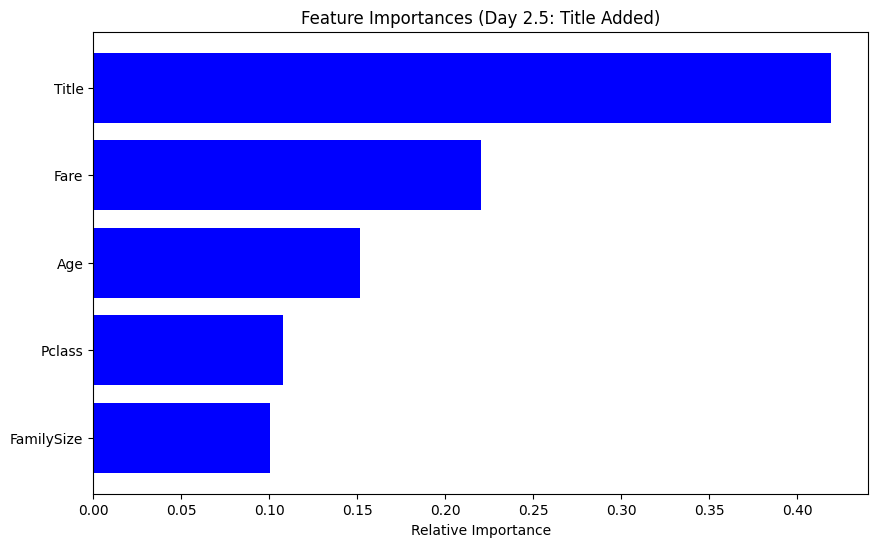

In [103]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 重要度を取得
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

# 2. グラフの描画
plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Day 2.5: Title Added)')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [125]:
from sklearn.model_selection import GridSearchCV

# 1. 試したいパラメータの候補をリストにする
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. グリッドサーチの実行（5分割交差検証）
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=0),
    param_grid=param_grid,
    cv=5, 
    n_jobs=-1, # 全CPUを使って高速化
    verbose=1
)

grid_search.fit(X_train, y_train)

# 3. 最良の組み合わせとスコアを表示
print(f"最良パラメータ: {grid_search.best_params_}")
print(f"交差検証での最高精度: {grid_search.best_score_:.2%}")

# 4. 最良のモデルでテストデータを予測
best_model = grid_search.best_estimator_
print(f"最終テストスコア: {best_model.score(X_test, y_test):.2%}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
最良パラメータ: {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
交差検証での最高精度: 84.27%
最終テストスコア: 82.12%
